# OIT 367 Final Project — Ethical Premium
## Full Analysis Notebook

This notebook is the structured, interactive version of `model.py`.
It analyses whether Ethisphere's **World's Most Ethical Companies (WMEC)** honorees
outperform the benchmark across five dimensions:

| # | Analysis | Question |
|---|----------|----------|
| 1 | **Downside Resilience** | Do honorees have lower max drawdowns? Do they recover faster? |
| 2 | **Consistency** | How often do honorees outperform (monthly, rolling, down months)? |
| 3 | **Upside / Downside Capture** | Do honorees capture more upside and less downside? |
| 4 | **Tail-Risk Story** | How do honorees behave in the worst market months? |
| 5 | **Segmentation** | Are there patterns by sector, country, industry, or company size? |

Figures are displayed **inline** and also saved to `output/`.

---
## Imports & Global Configuration

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

%matplotlib inline
warnings.filterwarnings('ignore')

np.random.seed(42)
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)
N_BOOTSTRAP = 10_000

print(f'Output directory: {OUTPUT_DIR}/')

Output directory: output/


### Brand Colours, Plot Style & Helper Functions

Sets the Ethisphere brand palette and default `rcParams` for all figures.  
Key helpers:
- `sig_stars(p)` — converts a p-value to significance stars (`***` / `**` / `*` / `.` / `ns`).
- `bootstrap_pvalue(dist, null)` — derives a p-value from a bootstrap distribution.
- `save_fig(name)` — saves the current figure to `output/` **and** displays it inline.
- `max_drawdown(series)` — returns the maximum peak-to-trough decline.
- `time_underwater(series)` — returns `(max_underwater_days, recovery_days)`.

In [2]:
# ── Brand palette ─────────────────────────────────────────────────────────────
BRAND_BLUE  = '#1a3a5c'
BRAND_GOLD  = '#c9a84c'
BRAND_RED   = '#c0392b'
BRAND_GREY  = '#7f8c8d'
BRAND_GREEN = '#27ae60'
BRAND_LIGHT = '#ecf0f1'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.edgecolor':   '#cccccc',
    'axes.grid':        True,
    'grid.color':       '#eeeeee',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'legend.fontsize':  9,
    'figure.dpi':       150,
})


def sig_stars(p):
    """Convert p-value to significance stars."""
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.10:  return '.'
    return 'ns'


def bootstrap_pvalue(bootstrap_dist, null_value, alternative='two-sided'):
    """Derive a p-value from a bootstrap distribution relative to a null value."""
    if alternative == 'greater':
        return np.mean(bootstrap_dist <= null_value)
    if alternative == 'less':
        return np.mean(bootstrap_dist >= null_value)
    centered = bootstrap_dist - np.mean(bootstrap_dist)
    observed = np.mean(bootstrap_dist) - null_value
    return np.mean(np.abs(centered) >= np.abs(observed))


def save_fig(name):
    """Save the current figure to output/ and display it inline."""
    path = os.path.join(OUTPUT_DIR, name)
    plt.savefig(path, bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()
    print(f'  Saved figure: {path}')


def max_drawdown(cum_series):
    """Return the maximum peak-to-trough percentage decline."""
    peak = cum_series.cummax()
    return ((cum_series - peak) / peak).min()


def time_underwater(cum_series):
    """
    Return (max_underwater_days, recovery_days) for a cumulative return series.

    - max_underwater_days : longest consecutive streak below a previous peak.
    - recovery_days       : trading days from max-drawdown trough back to a new
                            peak; np.nan if never recovered within the series.
    """
    peak = cum_series.cummax()
    underwater = cum_series < peak

    # Longest underwater streak
    streaks, current = [], 0
    for uw in underwater:
        if uw:
            current += 1
        else:
            if current > 0:
                streaks.append(current)
            current = 0
    if current > 0:
        streaks.append(current)
    max_uw = max(streaks) if streaks else 0

    # Recovery time from the max-drawdown trough
    dd = (cum_series - peak) / peak
    trough_idx  = dd.idxmin()
    trough_loc  = cum_series.index.get_loc(trough_idx)
    peak_at_trough = peak.iloc[trough_loc]
    post_trough = cum_series.iloc[trough_loc:]
    recovered   = post_trough[post_trough >= peak_at_trough]
    if len(recovered) > 0:
        recovery_loc  = cum_series.index.get_loc(recovered.index[0])
        recovery_days = recovery_loc - trough_loc
    else:
        recovery_days = np.nan

    return max_uw, recovery_days

---
## Data Loading

Three data sources are loaded:

1. **`CAPIQ Stocks and Daily Movement.csv`** — Daily prices for 113 honoree stocks (2021-2025).  
   Capital IQ export format: rows 0-7 are metadata; row 8 onward is daily price data.
2. **`Solactive_Ethic_Backtest_20260130.xlsx`** — Two sheets:  
   - `Performance`: daily index levels for the Ethics Premium GTR and SGMACUT benchmark (base = 1,000 on 2021-01-01).  
   - `Composition_Weights`: 113 ticker symbols and their portfolio weights at five annual rebalancing dates.
3. **`WMEC Stocks and Info.csv`** — Firmographic data (sector, country, revenue, workforce size, structure) for 118 companies.

In [3]:
# ── Stock prices (Capital IQ format) ──────────────────────────────────────────
raw = pd.read_csv('CAPIQ Stocks and Daily Movement.csv', header=None)

tickers       = raw.iloc[1, 2:].values   # row 1  = ticker symbols
exchanges     = raw.iloc[0, 2:].values   # row 0  = exchange names
company_names = raw.iloc[2, 2:].values   # row 2  = company names

prices = raw.iloc[8:, 2:].copy()         # rows 8+ = daily price data
prices.columns   = tickers
prices.index     = pd.to_datetime(raw.iloc[8:, 1], format='%m/%d/%Y')
prices.index.name = 'Date'
prices = prices.replace(',', '', regex=True).apply(pd.to_numeric, errors='coerce')
prices = prices.sort_index()
prices = prices[~prices.index.duplicated(keep='first')]

print(f'Stock prices: {prices.shape[0]} trading days x {prices.shape[1]} stocks')
print(f'Date range  : {prices.index.min().date()} → {prices.index.max().date()}')
prices.head()

Stock prices: 1304 trading days x 113 stocks
Date range  : 2021-01-01 → 2025-12-31


,LLY,V,MA,CRM,IBM,LIN,PEP,OR,ACN,VZ,...,TKR,ITRI,LEA,MOTV3,NATU3,BIMBOA,GT,PINC,SIG,CRI
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-01,159.96,210.51,346.45,219.86,97.20,245.93,127.11,288.85,240.16,42.80,...,70.78,95.90,141.37,11.86,50.10,159.96,10.91,5.39,25.66,77.88
2021-01-04,156.79,209.57,341.16,217.67,95.70,241.54,123.65,289.69,235.79,42.88,...,69.12,95.65,139.95,11.68,49.62,156.79,10.17,5.49,26.02,76.33
2021-01-05,157.57,206.45,337.21,218.86,97.40,245.33,124.02,286.72,237.13,42.68,...,71.20,96.42,142.38,11.49,49.33,157.57,10.64,5.46,27.87,76.86
2021-01-06,155.68,204.63,337.34,213.56,99.83,253.38,122.51,287.00,239.73,43.20,...,76.18,106.98,147.29,11.10,46.67,155.68,10.78,5.50,31.11,83.24
2021-01-07,157.11,205.77,340.01,215.36,99.60,252.66,122.11,285.88,241.99,43.10,...,77.66,107.27,151.48,11.12,46.27,157.11,10.74,5.49,33.10,82.96


In [4]:
# ── Solactive backtest: index performance ─────────────────────────────────────
perf = pd.read_excel(
    'Solactive_Ethic_Backtest_20260130.xlsx',
    sheet_name='Performance'
)
perf['Date'] = pd.to_datetime(perf['Date'])
perf = perf.set_index('Date')[['Ethics Premium GTR', 'SGMACUT Index']].copy()
perf = perf.sort_index()
perf = perf[~perf.index.duplicated(keep='first')]
perf.columns = ['EthicsPremium_GTR', 'Benchmark_GTR']

print(f'Performance data: {perf.shape[0]} trading days')
print(f'Date range       : {perf.index.min().date()} → {perf.index.max().date()}')

# ── Solactive backtest: composition & weights ──────────────────────────────────
weights = pd.read_excel(
    'Solactive_Ethic_Backtest_20260130.xlsx',
    sheet_name='Composition_Weights'
)
weights = weights.rename(columns={'Ticker': 'Ticker_Exch', 'Name': 'Company'})
weights['Ticker'] = weights['Ticker_Exch'].str.split('-').str[0]

print(f'\nComposition/Weights: {weights.shape[0]} constituents across '
      f'{weights.shape[1] - 3} rebalancing dates')
weights.head()

Performance data: 1304 trading days
Date range       : 2021-01-01 → 2025-12-31

Composition/Weights: 113 constituents across 6 rebalancing dates


,Ticker_Exch,Company,4/7/2020,4/7/2021,4/7/2022,4/7/2023,4/5/2024,4/7/2025,Ticker
0,LLY-NYS,Eli Lilly and Company,0.030015,0.027501,0.040249,0.051708,0.080000,0.080000,LLY
1,V-NYS,Visa Inc. Class A,0.062145,0.055158,0.054279,0.058151,0.056626,0.076196,V
2,MA-NYS,Mastercard Incorporated Class A,0.054300,0.053874,0.051146,0.054455,0.057192,0.062574,MA
3,CRM-NYS,"Salesforce, Inc.",0.029134,0.030011,0.031021,0.031654,0.037479,0.032549,CRM
4,IBM-NYS,International Business Machines Corporation,0.022268,0.018290,0.017257,0.018841,0.022459,0.029156,IBM


In [5]:
# ── Firmographic data ─────────────────────────────────────────────────────────
firmographics  = pd.read_csv('WMEC Stocks and Info.csv')
ticker_to_firm = firmographics.set_index('Symbol')
matched_tickers = [t for t in tickers if t in ticker_to_firm.index]

print(f'Firmographics: {firmographics.shape[0]} companies | '
      f'{firmographics.shape[1]} columns')
print(f'Tickers matched to firmographics: {len(matched_tickers)}')
print(f'Columns: {list(firmographics.columns)}')
firmographics.head()

Firmographics: 118 companies | 12 columns
Tickers matched to firmographics: 109
Columns: ['Company', 'Symbol', 'Exchange', 'Structure', 'Sectors', 'Industry Groups', 'Industries', 'Sub-Industries', 'Domicile Country', 'Workforce Size', 'Annual Revenue', 'Workforce Representation']


,Company,Symbol,Exchange,Structure,Sectors,Industry Groups,Industries,Sub-Industries,Domicile Country,Workforce Size,Annual Revenue,Workforce Representation
0,CME Group,CME,NASDAQ,Public,Financials,Financial Services,Capital Markets,Financial Exchanges & Data,United States,"1,000 - 4,999 employees","$5,000,000,001 - $10,000,000,000",NaN
1,DocGo,DCGO,NASDAQ,Public,Health Care,Health Care Equipment & Services,Health Care Providers & Services,Health Care Services,United States,"1,000 - 4,999 employees","Less than $500,000,000",NaN
2,"Premier, Inc.",PINC,NASDAQ,Public,Health Care,Health Care Equipment & Services,Health Care Technology,Health Care Technology,United States,"1,000 - 4,999 employees","$1,000,000,001 - $5,000,000,000",NaN
3,TrueBlue Inc.,TBI,NYSE,Public,Consumer Discretionary,Consumer Services,Diversified Consumer Services,Specialized Consumer Services,United States,"1,000 - 4,999 employees","$1,000,000,001 - $5,000,000,000",NaN
4,A.O. Smith,AOS,NYSE,Public,Industrials,Capital Goods,Building Products,Building Products,United States,"10,000 - 14,999 employees","$1,000,000,001 - $5,000,000,000",31-40 percent


---
## Returns Computation & Overview Chart

Daily and monthly returns are derived from prices using simple percentage changes.  
Monthly returns use the compounded product of daily returns (not end-of-month price changes)  
to preserve accuracy across varying month lengths.

The benchmark used throughout is the **SGMACUT Index** (Solactive Global Market Acumulated Cap  
Unhedged Total Return), which serves as the ETF-eligible universe benchmark.

**Figure 0** shows cumulative index performance for the Ethics Premium GTR vs. the benchmark,  
with green shading where EP outperforms and red where it underperforms.

In [6]:
# ── Daily returns ──────────────────────────────────────────────────────────────
stock_returns = prices.pct_change().iloc[1:]
bench_returns = perf.pct_change().iloc[1:]

common_dates  = stock_returns.index.intersection(bench_returns.index)
stock_returns = stock_returns.loc[common_dates]
bench_returns = bench_returns.loc[common_dates]

bm_daily = bench_returns['Benchmark_GTR']
ep_daily = bench_returns['EthicsPremium_GTR']

# ── Monthly returns (compounded daily) ────────────────────────────────────────
stock_monthly = stock_returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)
bm_monthly    = bm_daily.resample('ME').apply(lambda x: (1 + x).prod() - 1)

# ── Cumulative returns ─────────────────────────────────────────────────────────
stock_cum = (1 + stock_returns).cumprod()
bm_cum    = (1 + bm_daily).cumprod()

print(f'Aligned trading days : {len(common_dates)}')
print(f'Monthly return obs   : {len(bm_monthly)}')
print(f'Date range           : {common_dates.min().date()} → {common_dates.max().date()}')

Aligned trading days : 1303
Monthly return obs   : 60
Date range           : 2021-01-04 → 2025-12-31


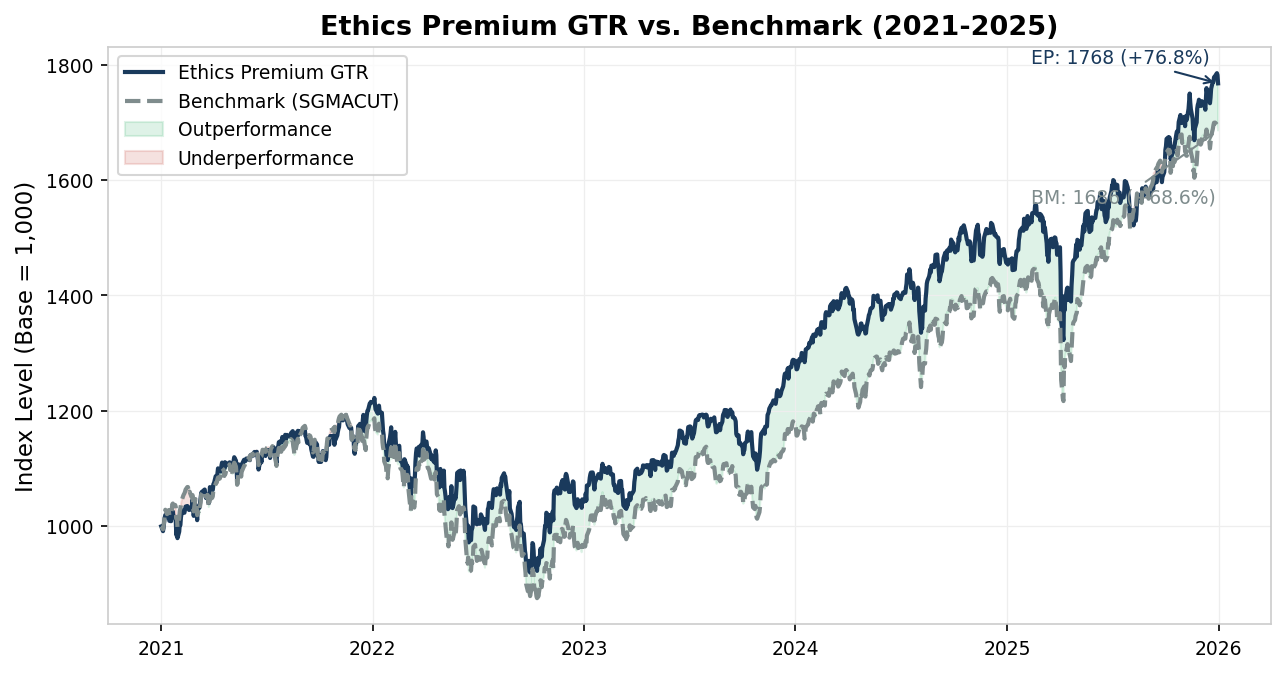

  Saved figure: output/fig0_index_performance.png


In [7]:
# ── Figure 0: Cumulative index performance ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(perf.index, perf['EthicsPremium_GTR'], color=BRAND_BLUE,
        linewidth=2, label='Ethics Premium GTR')
ax.plot(perf.index, perf['Benchmark_GTR'], color=BRAND_GREY,
        linewidth=2, linestyle='--', label='Benchmark (SGMACUT)')

ax.fill_between(perf.index,
                perf['EthicsPremium_GTR'], perf['Benchmark_GTR'],
                where=perf['EthicsPremium_GTR'] >= perf['Benchmark_GTR'],
                alpha=0.15, color=BRAND_GREEN, label='Outperformance')
ax.fill_between(perf.index,
                perf['EthicsPremium_GTR'], perf['Benchmark_GTR'],
                where=perf['EthicsPremium_GTR'] < perf['Benchmark_GTR'],
                alpha=0.15, color=BRAND_RED, label='Underperformance')

ax.set_title('Ethics Premium GTR vs. Benchmark (2021-2025)')
ax.set_ylabel('Index Level (Base = 1,000)')
ax.legend(loc='upper left')

final_ep = perf['EthicsPremium_GTR'].iloc[-1]
final_bm = perf['Benchmark_GTR'].iloc[-1]
ax.annotate(f"EP: {final_ep:.0f} (+{(final_ep/1000-1)*100:.1f}%)",
            xy=(perf.index[-1], final_ep), xytext=(-90, 10),
            textcoords='offset points', color=BRAND_BLUE, fontsize=9,
            arrowprops=dict(arrowstyle='->', color=BRAND_BLUE))
ax.annotate(f"BM: {final_bm:.0f} (+{(final_bm/1000-1)*100:.1f}%)",
            xy=(perf.index[-1], final_bm), xytext=(-90, -35),
            textcoords='offset points', color=BRAND_GREY, fontsize=9,
            arrowprops=dict(arrowstyle='->', color=BRAND_GREY))

save_fig('fig0_index_performance.png')

---
## Analysis 1: Downside Resilience

**Question:** Do WMEC honorees experience lower drawdowns and recover more quickly?

Three sub-metrics:
1. **Max Drawdown** — peak-to-trough percentage decline over the full period.  
   We compute max drawdown for each stock and the benchmark, then bootstrap the percentage of stocks that have a *less severe* drawdown than the benchmark.
2. **Time Underwater** — longest consecutive streak (in trading days) where the stock sits below its previous peak.
3. **Time-to-Recover** — trading days from the max-drawdown trough back to a new high.  
   `NaN` if the stock never fully recovered within the sample period.

Statistical tests: binomial test vs 50%, one-sample t-test vs benchmark level, Wilcoxon signed-rank.

In [8]:
print('=' * 70)
print('ANALYSIS 1: DOWNSIDE RESILIENCE — Max Drawdown')
print('=' * 70)

# ── Max drawdown for each stock and the benchmark ─────────────────────────────
stock_mdd = stock_cum.apply(max_drawdown)
bm_mdd    = max_drawdown(bm_cum)

valid_stocks   = stock_mdd.dropna()
n_stocks       = len(valid_stocks)
stock_mdd_vals = valid_stocks.values
beats_bm_mdd   = (stock_mdd_vals > bm_mdd).astype(float)  # less negative = better
n_beats_mdd    = int(beats_bm_mdd.sum())

# Bootstrap 95% CI for the share of stocks beating the benchmark
boot_mdd = np.array([
    beats_bm_mdd[np.random.randint(0, n_stocks, n_stocks)].mean()
    for _ in range(N_BOOTSTRAP)
])
ci_lo_mdd = np.percentile(boot_mdd, 2.5)
ci_hi_mdd = np.percentile(boot_mdd, 97.5)
pt_mdd    = beats_bm_mdd.mean()

print(f'Benchmark MDD         : {bm_mdd*100:.2f}%')
print(f'Stocks beating BM MDD : {n_beats_mdd}/{n_stocks} ({pt_mdd*100:.1f}%) '
      f'95% CI [{ci_lo_mdd*100:.1f}%, {ci_hi_mdd*100:.1f}%]')

ANALYSIS 1: DOWNSIDE RESILIENCE — Max Drawdown
Benchmark MDD         : -26.63%
Stocks beating BM MDD : 11/113 (9.7%) 95% CI [4.4%, 15.0%]


In [9]:
print('ANALYSIS 1: DOWNSIDE RESILIENCE — Time Underwater & Time-to-Recover')
print('=' * 70)

# ── Benchmark underwater stats ─────────────────────────────────────────────────
bm_uw, bm_recovery = time_underwater(bm_cum)

# ── Per-stock underwater stats ─────────────────────────────────────────────────
stock_uw, stock_recovery = {}, {}
for t in stock_cum.columns:
    uw, rec = time_underwater(stock_cum[t])
    stock_uw[t]       = uw
    stock_recovery[t] = rec

stock_uw_s       = pd.Series(stock_uw)
stock_recovery_s = pd.Series(stock_recovery)

# % of stocks with shorter max-underwater streak than benchmark
beats_uw   = (stock_uw_s < bm_uw).astype(float)
n_beats_uw = int(beats_uw.sum())

boot_uw  = np.array([
    beats_uw.values[np.random.randint(0, len(beats_uw), len(beats_uw))].mean()
    for _ in range(N_BOOTSTRAP)
])
ci_uw_lo = np.percentile(boot_uw, 2.5)
ci_uw_hi = np.percentile(boot_uw, 97.5)

# For histogram and median: only stocks that actually recovered within the sample
valid_rec = stock_recovery_s.dropna()
# For the beats comparison: stocks that never recovered are treated as taking
# np.inf days — always slower than any finite benchmark recovery. This keeps
# the denominator at the full 113 rather than silently excluding the worst
# performers who never made it back to a new high.
rec_for_comp = stock_recovery_s.fillna(np.inf)
if not np.isnan(bm_recovery):
    beats_rec   = (rec_for_comp < bm_recovery).astype(float)
    n_beats_rec = int(beats_rec.sum())
else:
    beats_rec   = pd.Series(dtype=float)
    n_beats_rec = 0

boot_rec = np.array([
    beats_rec.values[np.random.randint(0, len(beats_rec), len(beats_rec))].mean()
    for _ in range(N_BOOTSTRAP)
]) if len(beats_rec) > 0 else np.array([np.nan])
ci_rec_lo = np.percentile(boot_rec, 2.5)
ci_rec_hi = np.percentile(boot_rec, 97.5)

print(f'Benchmark : max underwater={bm_uw} days, '
      f'recovery={bm_recovery if not np.isnan(bm_recovery) else "never"} days')
print(f'Median stock : underwater={stock_uw_s.median():.0f} days, '
      f'recovery={valid_rec.median():.0f} days (of {len(valid_rec)} that recovered)')
print(f'Shorter underwater than BM : {n_beats_uw}/{len(beats_uw)} '
      f'({beats_uw.mean()*100:.1f}%) '
      f'95% CI [{ci_uw_lo*100:.1f}%, {ci_uw_hi*100:.1f}%]')
if not np.isnan(bm_recovery):
    print(f'Faster recovery than BM : {n_beats_rec}/{len(rec_for_comp)} '
          f'({beats_rec.mean()*100:.1f}%) '
          f'95% CI [{ci_rec_lo*100:.1f}%, {ci_rec_hi*100:.1f}%]')

ANALYSIS 1: DOWNSIDE RESILIENCE — Time Underwater & Time-to-Recover
Benchmark : max underwater=579 days, recovery=338 days
Median stock : underwater=562 days, recovery=283 days (of 70 that recovered)
Shorter underwater than BM : 58/113 (51.3%) 95% CI [42.5%, 61.1%]
Faster recovery than BM : 45/113 (39.8%) 95% CI [31.0%, 48.7%]


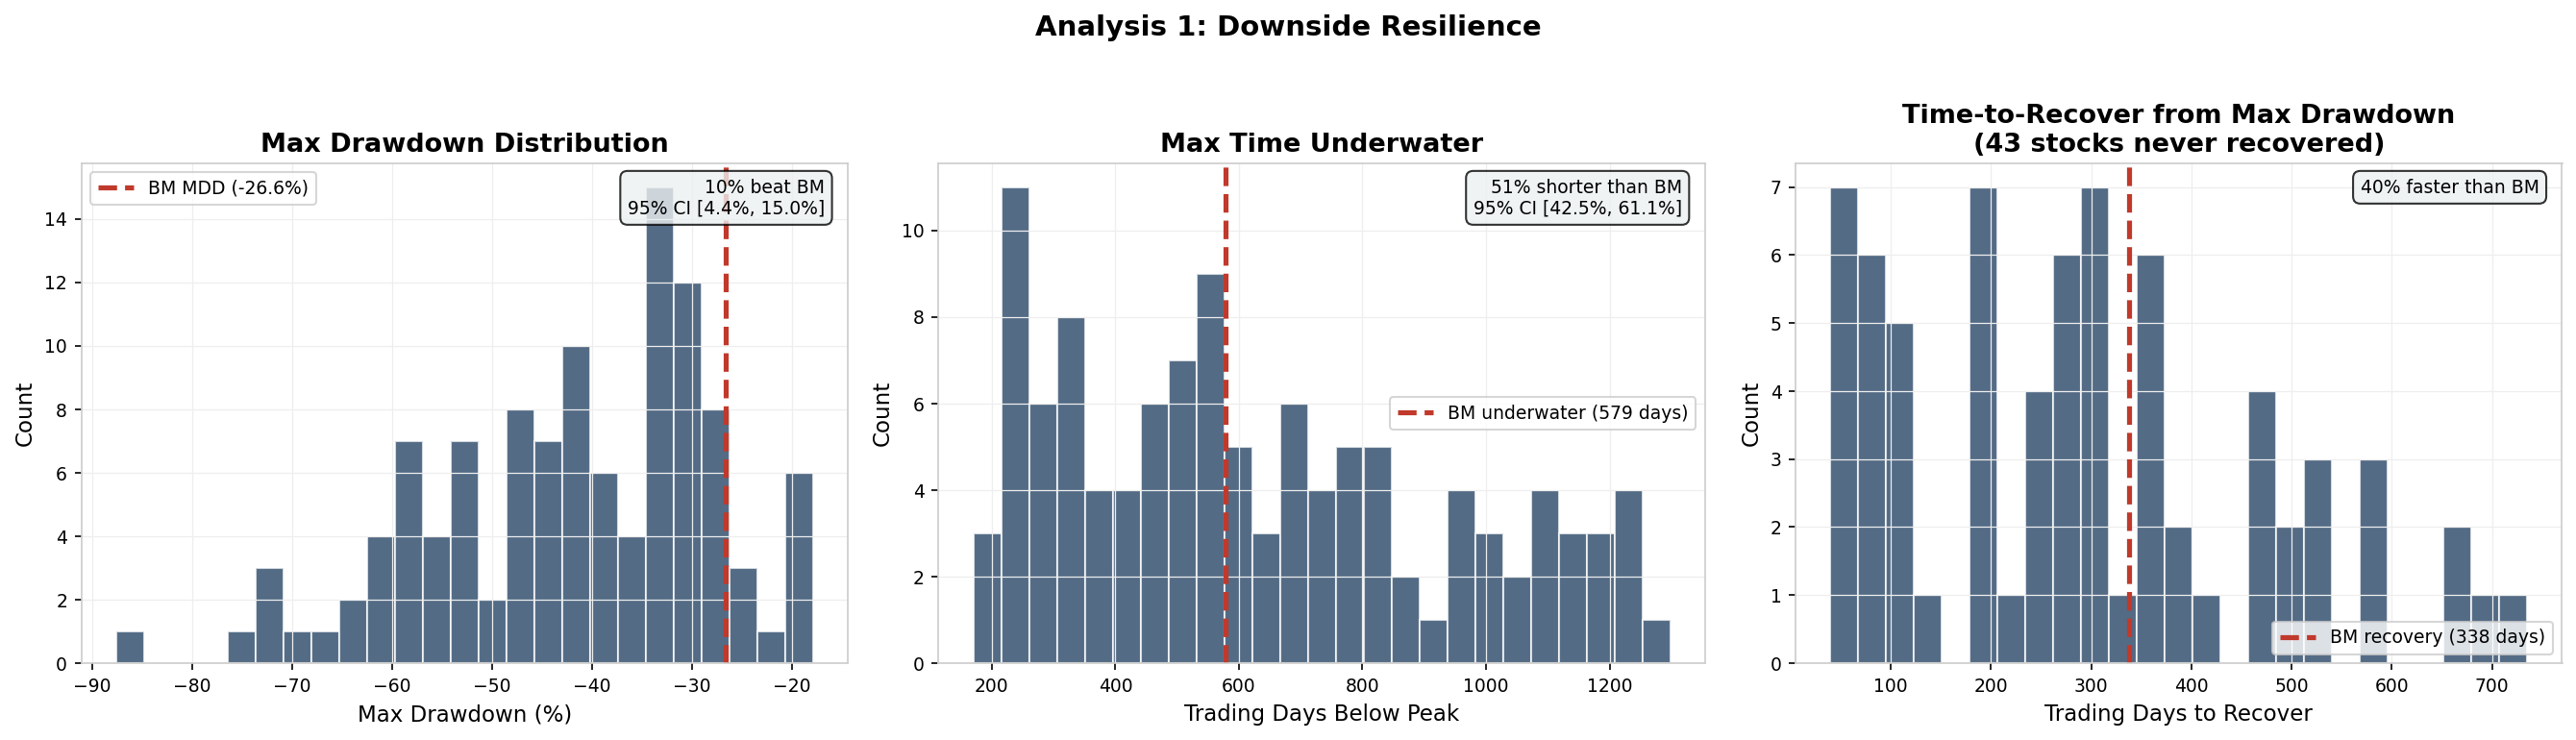

  Saved figure: output/fig1_downside_resilience.png


In [10]:
# ── Figure 1: Downside resilience — three histograms ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Max drawdown distribution
ax = axes[0]
ax.hist(stock_mdd_vals * 100, bins=25, color=BRAND_BLUE, alpha=0.75, edgecolor='white')
ax.axvline(bm_mdd * 100, color=BRAND_RED, linewidth=2.5, linestyle='--',
           label=f'BM MDD ({bm_mdd*100:.1f}%)')
ax.set_title('Max Drawdown Distribution')
ax.set_xlabel('Max Drawdown (%)')
ax.set_ylabel('Count')
ax.legend()
ax.text(0.97, 0.97,
        f'{pt_mdd*100:.0f}% beat BM\n95% CI [{ci_lo_mdd*100:.1f}%, {ci_hi_mdd*100:.1f}%]',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor=BRAND_LIGHT, alpha=0.8))

# (b) Time underwater distribution
ax = axes[1]
ax.hist(stock_uw_s.values, bins=25, color=BRAND_BLUE, alpha=0.75, edgecolor='white')
ax.axvline(bm_uw, color=BRAND_RED, linewidth=2.5, linestyle='--',
           label=f'BM underwater ({bm_uw} days)')
ax.set_title('Max Time Underwater')
ax.set_xlabel('Trading Days Below Peak')
ax.set_ylabel('Count')
ax.legend()
ax.text(0.97, 0.97,
        f'{beats_uw.mean()*100:.0f}% shorter than BM\n'
        f'95% CI [{ci_uw_lo*100:.1f}%, {ci_uw_hi*100:.1f}%]',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor=BRAND_LIGHT, alpha=0.8))

# (c) Time-to-recover distribution
ax = axes[2]
rec_vals  = valid_rec.values
n_never   = stock_recovery_s.isna().sum()
ax.hist(rec_vals, bins=25, color=BRAND_BLUE, alpha=0.75, edgecolor='white')
if not np.isnan(bm_recovery):
    ax.axvline(bm_recovery, color=BRAND_RED, linewidth=2.5, linestyle='--',
               label=f'BM recovery ({bm_recovery:.0f} days)')
ax.set_title(f'Time-to-Recover from Max Drawdown\n({n_never} stocks never recovered)')
ax.set_xlabel('Trading Days to Recover')
ax.set_ylabel('Count')
ax.legend(loc='lower right')
if not np.isnan(bm_recovery):
    ax.text(0.97, 0.97,
            f'{beats_rec.mean()*100:.0f}% faster than BM',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4', facecolor=BRAND_LIGHT, alpha=0.8))

plt.suptitle('Analysis 1: Downside Resilience', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('fig1_downside_resilience.png')

---
## Analysis 2: Consistency

**Question:** How consistently do honorees outperform the benchmark?

Three layers of consistency:
1. **Monthly Hit Rate** — for each stock, the fraction of months it beat the benchmark.  
   We bootstrap the cross-stock mean to get a 95% CI.
2. **Rolling Hit Rate** — repeat using compounded 3-month and 6-month windows  
   (advancing one month at a time) to test whether consistency holds over longer horizons.
3. **Down-Month Hit Rate** — restrict to months where the *benchmark* return is negative  
   and ask: in those bad months, what share of honorees still outperform (i.e., fall less)?

Statistical tests: one-sample t-test and Wilcoxon signed-rank vs. a 50% null (coin-flip baseline).

In [ ]:
print('=' * 70)
print('ANALYSIS 2: CONSISTENCY — Monthly Hit Rate')
print('=' * 70)

# ── Monthly hit rate per stock ─────────────────────────────────────────────────
monthly_outperform = stock_monthly.gt(bm_monthly, axis=0)
stock_hit_rates    = monthly_outperform.mean()
valid_hit_rates    = stock_hit_rates.dropna()
n_stocks_hr        = len(valid_hit_rates)
hr_vals            = valid_hit_rates.values

# Bootstrap 95% CI for the cross-stock mean hit rate
boot_hr = np.array([
    hr_vals[np.random.randint(0, n_stocks_hr, n_stocks_hr)].mean()
    for _ in range(N_BOOTSTRAP)
])
ci_lo_hr = np.percentile(boot_hr, 2.5)
ci_hi_hr = np.percentile(boot_hr, 97.5)
pt_hr    = hr_vals.mean()

ts_hr, p_hr_t = stats.ttest_1samp(hr_vals, 0.5)
ws_hr, p_hr_w = stats.wilcoxon(hr_vals - 0.5)
p_hr_b        = bootstrap_pvalue(boot_hr, 0.5)

print(f'Monthly Hit Rate : {pt_hr*100:.1f}% '
      f'95% CI [{ci_lo_hr*100:.1f}%, {ci_hi_hr*100:.1f}%]')
print(f'  T-test p={p_hr_t:.4f} {sig_stars(p_hr_t)} | '
      f'Wilcoxon p={p_hr_w:.4f} {sig_stars(p_hr_w)}')

In [ ]:
print('ANALYSIS 2: CONSISTENCY — Rolling Hit Rates (3-month & 6-month)')
print('=' * 70)

def rolling_hit_rate(sm, bm, window):
    """Compute the rolling hit rate over `window` months for each stock."""
    sr = sm.rolling(window).apply(lambda x: (1 + x).prod() - 1, raw=True)
    br = bm.rolling(window).apply(lambda x: (1 + x).prod() - 1, raw=True)
    return sr.gt(br, axis=0).dropna(how='all').mean()


results_rolling = {}
for wname, wsz in [('3-Month', 3), ('6-Month', 6)]:
    rhr    = rolling_hit_rate(stock_monthly, bm_monthly, wsz).dropna()
    n_r    = len(rhr)
    r_vals = rhr.values
    boot_r = np.array([
        r_vals[np.random.randint(0, n_r, n_r)].mean()
        for _ in range(N_BOOTSTRAP)
    ])
    ts, pv = stats.ttest_1samp(r_vals, 0.5)
    ws, wp = stats.wilcoxon(r_vals - 0.5)
    results_rolling[wname] = dict(
        pt=r_vals.mean(),
        ci_lo=np.percentile(boot_r, 2.5),
        ci_hi=np.percentile(boot_r, 97.5),
        p_t=pv, p_w=wp
    )
    print(f'{wname} Rolling Hit Rate : {r_vals.mean()*100:.1f}% '
          f'95% CI [{np.percentile(boot_r,2.5)*100:.1f}%, '
          f'{np.percentile(boot_r,97.5)*100:.1f}%] '
          f'T-test p={pv:.4f} {sig_stars(pv)}')

In [ ]:
print('ANALYSIS 2: CONSISTENCY — Down-Month Hit Rate')
print('=' * 70)

down_months = bm_monthly[bm_monthly < 0].index
print(f'Number of down months (benchmark < 0): {len(down_months)}')

if len(down_months) > 0:
    stock_down    = stock_monthly.loc[down_months]
    bm_down       = bm_monthly.loc[down_months]
    down_op       = stock_down.gt(bm_down, axis=0)
    stock_down_hr = down_op.mean()
    valid_down_hr = stock_down_hr.dropna()
    d_vals        = valid_down_hr.values

    boot_d = np.array([
        d_vals[np.random.randint(0, len(d_vals), len(d_vals))].mean()
        for _ in range(N_BOOTSTRAP)
    ])
    pt_d    = d_vals.mean()
    ci_d_lo = np.percentile(boot_d, 2.5)
    ci_d_hi = np.percentile(boot_d, 97.5)
    ts_d, p_d_t = stats.ttest_1samp(d_vals, 0.5)
    ws_d, p_d_w = stats.wilcoxon(d_vals - 0.5)

    print(f'Down-Month Hit Rate : {pt_d*100:.1f}% '
          f'95% CI [{ci_d_lo*100:.1f}%, {ci_d_hi*100:.1f}%]')
    print(f'  T-test p={p_d_t:.4f} {sig_stars(p_d_t)} | '
          f'Wilcoxon p={p_d_w:.4f} {sig_stars(p_d_w)}')
else:
    pt_d = ci_d_lo = ci_d_hi = p_d_t = p_d_w = np.nan
    stock_down_hr = pd.Series(dtype=float)
    print('No down months found in the sample period.')

In [ ]:
# ── Figure 2: Consistency ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Per-stock monthly hit rate histogram
ax = axes[0]
ax.hist(hr_vals * 100, bins=25, color=BRAND_BLUE, alpha=0.75, edgecolor='white')
ax.axvline(50, color=BRAND_RED, linewidth=2, linestyle='--', label='50% (random)')
ax.axvline(pt_hr * 100, color=BRAND_GOLD, linewidth=2,
           label=f'Mean: {pt_hr*100:.1f}%')
ax.set_title('Per-Stock Monthly Hit Rate Distribution')
ax.set_xlabel('Monthly Hit Rate (%)')
ax.set_ylabel('Count')
ax.legend()
ax.text(0.97, 0.97,
        f'T-test vs 50%: p={p_hr_t:.3f} {sig_stars(p_hr_t)}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor=BRAND_LIGHT, alpha=0.8))

# (b) Hit rates across horizons (bar chart with error bars)
ax = axes[1]
labels = ['Monthly', '3-Month\nRolling', '6-Month\nRolling', 'Down-Month']
pts   = [pt_hr, results_rolling['3-Month']['pt'],
         results_rolling['6-Month']['pt'], pt_d]
lows  = [ci_lo_hr, results_rolling['3-Month']['ci_lo'],
         results_rolling['6-Month']['ci_lo'], ci_d_lo]
highs = [ci_hi_hr, results_rolling['3-Month']['ci_hi'],
         results_rolling['6-Month']['ci_hi'], ci_d_hi]
x = np.arange(len(labels))
bars = ax.bar(x, [p * 100 for p in pts],
              color=[BRAND_BLUE, BRAND_BLUE, BRAND_BLUE, BRAND_GOLD],
              alpha=0.8, width=0.5, edgecolor='white')
for j in range(len(x)):
    if not np.isnan(lows[j]):
        ax.errorbar(x[j], pts[j]*100,
                    yerr=[[pts[j]*100 - lows[j]*100], [highs[j]*100 - pts[j]*100]],
                    fmt='none', color='black', capsize=5, linewidth=1.5)
ax.axhline(50, color=BRAND_RED, linewidth=1.5, linestyle='--', label='50%')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 80)
ax.set_ylabel('Hit Rate (%)')
ax.set_title('Hit Rates Across Horizons (Error bars = 95% CI)')
ax.legend()
for bar, pt in zip(bars, pts):
    if not np.isnan(pt):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f'{pt*100:.1f}%', ha='center', fontsize=9, fontweight='bold')

save_fig('fig2_consistency.png')

---
## Analysis 3: Upside / Downside Capture

**Question:** Do honorees capture a greater share of the benchmark's up-moves and a smaller share of its down-moves?

**Capture ratio** = average stock return on up (or down) days ÷ average benchmark return on those days.  
- Upside capture > 100% → honoree gains *more* than the benchmark on good days.  
- Downside capture < 100% → honoree loses *less* than the benchmark on bad days.

**Nested bootstrap** (10,000 iterations):  
1. Randomly select a contiguous 60-trading-day window (eliminates endpoint bias).  
2. Within that window, resample stocks with replacement.  
3. Record the share of sampled stocks with upside capture > 100% and downside capture < 100%.  

This yields a 95% CI for each capture metric across random market regimes.

In [ ]:
print('=' * 70)
print('ANALYSIS 3: UPSIDE / DOWNSIDE CAPTURE — Full-Period Ratios')
print('=' * 70)

WINDOW_SIZE = 60
n_days      = len(stock_returns)
max_start   = n_days - WINDOW_SIZE
up_days     = bm_daily > 0
down_days   = bm_daily < 0

# ── Full-period capture ratios per stock ───────────────────────────────────────
stock_up_capture, stock_down_capture = {}, {}
for t in stock_returns.columns:
    sr = stock_returns[t]
    if up_days.sum() > 0:
        stock_up_capture[t]   = sr[up_days].mean() / bm_daily[up_days].mean()
    if down_days.sum() > 0:
        stock_down_capture[t] = sr[down_days].mean() / bm_daily[down_days].mean()

up_cap_s   = pd.Series(stock_up_capture)
down_cap_s = pd.Series(stock_down_capture)

ts_uc, p_uc_t = stats.ttest_1samp(up_cap_s.dropna().values, 1.0)
ts_dc, p_dc_t = stats.ttest_1samp(down_cap_s.dropna().values, 1.0)
ws_uc, p_uc_w = stats.wilcoxon(up_cap_s.dropna().values - 1.0)
ws_dc, p_dc_w = stats.wilcoxon(down_cap_s.dropna().values - 1.0)

print(f'Avg upside capture   : {up_cap_s.mean()*100:.1f}% '
      f'T-test vs 100% p={p_uc_t:.4f} {sig_stars(p_uc_t)}')
print(f'Avg downside capture : {down_cap_s.mean()*100:.1f}% '
      f'T-test vs 100% p={p_dc_t:.4f} {sig_stars(p_dc_t)}')

In [ ]:
print('ANALYSIS 3: UPSIDE / DOWNSIDE CAPTURE — Nested Bootstrap')
print('=' * 70)

stock_ret_arr = stock_returns.values
bm_arr        = bm_daily.values
n_stocks_cap  = stock_ret_arr.shape[1]
boot_up       = np.empty(N_BOOTSTRAP)
boot_dn       = np.empty(N_BOOTSTRAP)

print(f'Running nested bootstrap ({N_BOOTSTRAP:,} iterations) ...')
for i in range(N_BOOTSTRAP):
    start  = np.random.randint(0, max_start + 1)
    wstock = stock_ret_arr[start:start + WINDOW_SIZE, :]
    wbm    = bm_arr[start:start + WINDOW_SIZE]
    w_up   = wbm > 0
    w_dn   = wbm < 0
    samp   = np.random.randint(0, n_stocks_cap, size=n_stocks_cap)
    uc = np.full(n_stocks_cap, np.nan)
    dc = np.full(n_stocks_cap, np.nan)
    if w_up.sum() > 0:
        mu = wbm[w_up].mean()
        if mu != 0:
            uc = wstock[w_up, :][:, samp].mean(axis=0) / mu
    if w_dn.sum() > 0:
        md = wbm[w_dn].mean()
        if md != 0:
            dc = wstock[w_dn, :][:, samp].mean(axis=0) / md
    boot_up[i] = np.nanmean(uc > 1)
    boot_dn[i] = np.nanmean(dc < 1)

bpu = boot_up[~np.isnan(boot_up)]
bpd = boot_dn[~np.isnan(boot_dn)]
up_pt, up_ci_lo, up_ci_hi = bpu.mean(), np.percentile(bpu, 2.5), np.percentile(bpu, 97.5)
dn_pt, dn_ci_lo, dn_ci_hi = bpd.mean(), np.percentile(bpd, 2.5), np.percentile(bpd, 97.5)
p_boot_uc = bootstrap_pvalue(bpu, 0.5, 'greater')
p_boot_dc = bootstrap_pvalue(bpd, 0.5, 'greater')

print(f'Upside capture > 100%  : {up_pt*100:.1f}% '
      f'95% CI [{up_ci_lo*100:.1f}%, {up_ci_hi*100:.1f}%] '
      f'p={p_boot_uc:.4f} {sig_stars(p_boot_uc)}')
print(f'Downside capture < 100%: {dn_pt*100:.1f}% '
      f'95% CI [{dn_ci_lo*100:.1f}%, {dn_ci_hi*100:.1f}%] '
      f'p={p_boot_dc:.4f} {sig_stars(p_boot_dc)}')

In [ ]:
# ── Figure 3: Capture ratios ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (a) Scatter: upside vs downside capture, coloured by sector
ax = axes[0]
uc_v = up_cap_s.values * 100
dc_v = down_cap_s.reindex(up_cap_s.index).values * 100
sector_map     = firmographics.set_index('Symbol')['Sectors']
sector_palette = dict(zip(
    firmographics['Sectors'].dropna().unique(),
    sns.color_palette('tab10', n_colors=12)
))
colors_s = []
for t in up_cap_s.index:
    sv = sector_map.get(t, None)
    if isinstance(sv, pd.Series):
        sv = sv.iloc[0]
    colors_s.append(sector_palette.get(sv, BRAND_GREY))

ax.scatter(uc_v, dc_v, c=colors_s, alpha=0.75, s=60, edgecolors='white')
ax.axhline(100, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.axvline(100, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Upside Capture (%)')
ax.set_ylabel('Downside Capture (%)')
ax.set_title('Upside vs. Downside Capture\n(Ideal: right of 100%, below 100%)')
sector_counts = firmographics.groupby('Sectors').size()
for sec, color in sector_palette.items():
    if sector_counts.get(sec, 0) >= 3:
        ax.scatter([], [], c=[color], label=sec, s=40, alpha=0.8)
ax.legend(fontsize=7, loc='upper left', ncol=2)
ax.text(0.97, 0.03,
        f'Upside T-test vs 100%: p={p_uc_t:.3f} {sig_stars(p_uc_t)}\n'
        f'Downside T-test vs 100%: p={p_dc_t:.3f} {sig_stars(p_dc_t)}',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.4', facecolor=BRAND_LIGHT, alpha=0.8))

# (b) Overlapping bootstrap distributions
ax = axes[1]
ax.hist(bpu * 100, bins=50, color=BRAND_GREEN, alpha=0.6,
        label=f'Up capture > 100% ({up_pt*100:.1f}%)', edgecolor='white')
ax.hist(bpd * 100, bins=50, color=BRAND_BLUE, alpha=0.6,
        label=f'Down capture < 100% ({dn_pt*100:.1f}%)', edgecolor='white')
ax.axvline(50, color=BRAND_RED, linewidth=1.5, linestyle='--', label='50% (null)')
ax.set_xlabel('% of Stocks with Superior Capture')
ax.set_ylabel('Bootstrap Frequency')
ax.set_title('Nested Bootstrap — Capture Profiles')
ax.legend()

save_fig('fig3_capture_ratios.png')

---
## Analysis 4: Tail-Risk Story

**Question:** How do honorees behave in the very worst market months?

We identify the **bottom 5% of benchmark months** (tail months) and compute three metrics:
1. **Avg excess return** — how many percentage points less do honorees fall on average?
2. **Hit rate** — in what fraction of (stock × tail-month) pairs does the stock beat the benchmark?
3. **Breadth** — on average, how many individual stocks beat the benchmark in each tail month?

All three metrics use 95% bootstrap CIs (resampling stocks with replacement across all tail months).

We also examine **drawdown clustering** — whether honoree pairwise return correlations are higher  
on down-market days vs. all days (a paired t-test). High clustering would mean honorees  
tend to fall *together* in bad markets, reducing diversification.

In [ ]:
print('=' * 70)
print('ANALYSIS 4: TAIL-RISK STORY — Worst Market Months')
print('=' * 70)

# ── Identify tail months (bottom 5% of benchmark monthly returns) ──────────────
threshold_pct = 5
threshold_val = np.percentile(bm_monthly.dropna(), threshold_pct)
worst_months  = bm_monthly[bm_monthly <= threshold_val].index

stock_worst = stock_monthly.loc[worst_months]
bm_worst    = bm_monthly.loc[worst_months]

print(f'Tail threshold (bottom {threshold_pct}%): {threshold_val*100:.2f}%')
print(f'Worst months identified: {[d.strftime("%Y-%m") for d in worst_months]}')

# ── Point estimates ─────────────────────────────────────────────────────────────
avg_stock_worst = stock_worst.mean(axis=1).mean()
avg_bm_worst    = bm_worst.mean()
avg_excess      = avg_stock_worst - avg_bm_worst

worst_outperform = stock_worst.gt(bm_worst, axis=0)
worst_hit_rates  = worst_outperform.mean()
valid_worst_hr   = worst_hit_rates.dropna()
breadth          = worst_outperform.sum(axis=1)
total_stocks_w   = stock_worst.shape[1]

# ── Statistical tests ──────────────────────────────────────────────────────────
stock_worst_means = stock_worst.mean(axis=0).dropna()
excess_per_stock  = stock_worst_means.values - avg_bm_worst
ts_tail, p_tail_t = stats.ttest_1samp(excess_per_stock, 0)
ws_tail, p_tail_w = stats.wilcoxon(excess_per_stock)
n_beats_tail      = int((valid_worst_hr.values > 0.5).sum())
p_binom_tail      = stats.binomtest(
    n_beats_tail, len(valid_worst_hr), 0.5, alternative='greater'
).pvalue

# ── Bootstrap 95% CIs ─────────────────────────────────────────────────────────
boot_excess = np.array([
    stock_worst_means.values[np.random.randint(
        0, len(stock_worst_means), len(stock_worst_means)
    )].mean() - avg_bm_worst
    for _ in range(N_BOOTSTRAP)
])
boot_whr = np.array([
    valid_worst_hr.values[np.random.randint(
        0, len(valid_worst_hr), len(valid_worst_hr)
    )].mean()
    for _ in range(N_BOOTSTRAP)
])
boot_breadth = np.array([
    breadth.values[np.random.randint(0, len(breadth), len(breadth))].mean()
    for _ in range(N_BOOTSTRAP)
])

ci_ex_lo  = np.percentile(boot_excess,  2.5)
ci_ex_hi  = np.percentile(boot_excess,  97.5)
ci_whr_lo = np.percentile(boot_whr,     2.5)
ci_whr_hi = np.percentile(boot_whr,     97.5)
ci_br_lo  = np.percentile(boot_breadth, 2.5)
ci_br_hi  = np.percentile(boot_breadth, 97.5)

print(f'Avg excess return : {avg_excess*100:.2f}% '
      f'95% CI [{ci_ex_lo*100:.2f}%, {ci_ex_hi*100:.2f}%] '
      f'T-test p={p_tail_t:.4f} {sig_stars(p_tail_t)}')
print(f'Hit rate          : {valid_worst_hr.mean()*100:.1f}% '
      f'95% CI [{ci_whr_lo*100:.1f}%, {ci_whr_hi*100:.1f}%] '
      f'Binomial p={p_binom_tail:.4f} {sig_stars(p_binom_tail)}')
print(f'Breadth           : {breadth.mean():.0f} '
      f'95% CI [{ci_br_lo:.0f}, {ci_br_hi:.0f}] / {total_stocks_w} stocks')

In [ ]:
print('ANALYSIS 4: TAIL-RISK STORY — Drawdown Clustering')
print('=' * 70)

# ── Pairwise correlations: down-market days vs all days ────────────────────────
down_market_days  = bm_daily[bm_daily < 0].index
stock_down_daily  = stock_returns.loc[down_market_days]

corr_matrix      = stock_down_daily.corr()
corr_matrix_all  = stock_returns.corr()

mask_tri           = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
pairwise_corrs     = corr_matrix.values[mask_tri]
pairwise_corrs_all = corr_matrix_all.values[mask_tri]

avg_corr_down = np.nanmean(pairwise_corrs)
avg_corr_all  = np.nanmean(pairwise_corrs_all)

ts_corr, p_corr = stats.ttest_rel(pairwise_corrs, pairwise_corrs_all)

pct_neg_worst = (stock_worst < 0).mean(axis=1)

print(f'Avg pairwise correlation (all days)  : {avg_corr_all:.3f}')
print(f'Avg pairwise correlation (down days) : {avg_corr_down:.3f}')
print(f'Paired t-test (down > all)           : p={p_corr:.4f} {sig_stars(p_corr)}')
print(f'Avg % honorees with negative return in worst months: '
      f'{pct_neg_worst.mean()*100:.1f}%')

In [ ]:
# ── Figure 4: Tail-risk story ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Worst months: honoree avg vs benchmark
ax = axes[0]
mlabels = [d.strftime('%b %Y') for d in worst_months]
x, w   = np.arange(len(worst_months)), 0.35
ax.bar(x - w/2, bm_worst.values * 100, w,
       label='Benchmark', color=BRAND_GREY, alpha=0.85, edgecolor='white')
ax.bar(x + w/2, stock_worst.mean(axis=1).values * 100, w,
       label='Avg Honoree', color=BRAND_BLUE, alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(mlabels, rotation=15)
ax.set_ylabel('Return (%)')
ax.set_title(f'Worst Months — Avg Excess: {avg_excess*100:.2f}%\n'
             f'T-test p={p_tail_t:.3f} {sig_stars(p_tail_t)}')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()

# (b) Breadth: stocks beating benchmark per tail month
ax = axes[1]
bars = ax.bar(mlabels, breadth.values, color=BRAND_BLUE, alpha=0.8, edgecolor='white')
ax.axhline(total_stocks_w / 2, color=BRAND_RED, linewidth=1.5, linestyle='--',
           label='50% of stocks')
ax.set_ylabel('Stocks Beating Benchmark')
ax.set_title(f'Breadth — Avg {breadth.mean():.0f}/{total_stocks_w} per month')
for bar, val in zip(bars, breadth.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(val)), ha='center', fontsize=10, fontweight='bold')
ax.legend()

# (c) Drawdown clustering: pairwise correlation histograms
ax = axes[2]
ax.hist(pairwise_corrs_all, bins=50, alpha=0.5, color=BRAND_GREY,
        label=f'All days (avg={avg_corr_all:.3f})', edgecolor='white')
ax.hist(pairwise_corrs, bins=50, alpha=0.5, color=BRAND_RED,
        label=f'Down days (avg={avg_corr_down:.3f})', edgecolor='white')
ax.set_xlabel('Pairwise Return Correlation')
ax.set_ylabel('Frequency')
ax.set_title(f'Drawdown Clustering\np={p_corr:.4f} {sig_stars(p_corr)}')
ax.legend()

plt.suptitle('Analysis 4: Tail-Risk Story', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('fig4_tail_risk.png')

---
## Analysis 5: Segmentation

**Question:** Are there meaningful performance differences across company characteristics?

We segment honorees across six dimensions:

| Dimension | Column |
|-----------|--------|
| Sector | `Sectors` |
| Industry Group | `Industry Groups` |
| Country | `Domicile Country` |
| Workforce Size | `Workforce Size` |
| Annual Revenue | `Annual Revenue` |
| Structure | `Structure` |

For each dimension we compute segment-level averages for all key metrics and run a  
**Kruskal-Wallis test** on monthly hit rate (non-parametric ANOVA) to assess whether  
differences across segments are statistically significant.

Outputs saved to `output/`:
- `stock_level_results.csv` — one row per stock with all analysis metrics.
- `segment_results.csv` — one row per segment × dimension with aggregated metrics.

In [ ]:
print('=' * 70)
print('ANALYSIS 5: SEGMENTATION — Build Stock-Level Summary')
print('=' * 70)

# ── Assemble per-stock metrics into a single DataFrame ────────────────────────
stock_summary = pd.DataFrame({
    'Ticker':               list(tickers),
    'Max_Drawdown_Pct':     stock_mdd.reindex(tickers).values * 100,
    'Time_Underwater_Days': stock_uw_s.reindex(tickers).values,
    'Recovery_Days':        stock_recovery_s.reindex(tickers).values,
    'Monthly_Hit_Rate_Pct': stock_hit_rates.reindex(tickers).values * 100,
    'Upside_Capture_Pct':   up_cap_s.reindex(tickers).values * 100,
    'Downside_Capture_Pct': down_cap_s.reindex(tickers).values * 100,
    'Down_Month_HR_Pct':    (stock_down_hr.reindex(tickers).values * 100
                             if len(down_months) > 0 else np.nan),
    'Worst_Month_HR_Pct':   worst_hit_rates.reindex(tickers).values * 100,
}).merge(
    firmographics[['Symbol', 'Sectors', 'Industry Groups', 'Domicile Country',
                   'Workforce Size', 'Annual Revenue', 'Structure']],
    left_on='Ticker', right_on='Symbol', how='left'
).drop(columns=['Symbol'])

# Save stock-level results
stock_summary.to_csv(os.path.join(OUTPUT_DIR, 'stock_level_results.csv'), index=False)
print(f'Saved stock_level_results.csv ({stock_summary.shape[0]} rows)')
stock_summary.head()

In [ ]:
print('ANALYSIS 5: SEGMENTATION — Segment Aggregation & Kruskal-Wallis Tests')
print('=' * 70)

segment_dims = {
    'Sector':         'Sectors',
    'Industry_Group': 'Industry Groups',
    'Country':        'Domicile Country',
    'Workforce_Size': 'Workforce Size',
    'Revenue':        'Annual Revenue',
    'Structure':      'Structure',
}

seg_frames = []
for seg_label, seg_col in segment_dims.items():
    if seg_col not in stock_summary.columns:
        continue
    grouped = stock_summary.dropna(subset=[seg_col]).groupby(seg_col)
    seg = grouped.agg(
        N=('Ticker', 'count'),
        Avg_MDD_Pct=('Max_Drawdown_Pct', 'mean'),
        Avg_Underwater_Days=('Time_Underwater_Days', 'mean'),
        Avg_Monthly_HR_Pct=('Monthly_Hit_Rate_Pct', 'mean'),
        Avg_Up_Capture_Pct=('Upside_Capture_Pct', 'mean'),
        Avg_Dn_Capture_Pct=('Downside_Capture_Pct', 'mean'),
        Avg_Down_Month_HR_Pct=('Down_Month_HR_Pct', 'mean'),
        Avg_Worst_Month_HR_Pct=('Worst_Month_HR_Pct', 'mean'),
    ).round(2)
    seg = seg[seg['N'] >= 3].sort_values('Avg_Monthly_HR_Pct', ascending=False)
    seg.insert(0, 'Segment_Type', seg_label)
    seg.index.name = 'Segment_Value'
    seg = seg.reset_index()
    seg_frames.append(seg)

    # Kruskal-Wallis: does monthly hit rate differ significantly across segments?
    groups = [
        g['Monthly_Hit_Rate_Pct'].dropna().values
        for _, g in stock_summary.dropna(
            subset=[seg_col, 'Monthly_Hit_Rate_Pct']
        ).groupby(seg_col)
        if len(g) >= 3
    ]
    if len(groups) >= 2:
        kw_stat, kw_p = stats.kruskal(*groups)
        print(f'\n{seg_label}: KW H={kw_stat:.2f}, p={kw_p:.4f} {sig_stars(kw_p)}')
    print(seg[['Segment_Value', 'N', 'Avg_Monthly_HR_Pct',
               'Avg_Up_Capture_Pct', 'Avg_Dn_Capture_Pct']].to_string(index=False))

# Save segment results
all_segments = pd.concat(seg_frames, ignore_index=True)
all_segments.to_csv(os.path.join(OUTPUT_DIR, 'segment_results.csv'), index=False)
print(f'\nSaved segment_results.csv ({all_segments.shape[0]} rows)')

In [ ]:
# ── Figure 5a: Sector metrics bar chart ───────────────────────────────────────
sec_seg = all_segments[all_segments['Segment_Type'] == 'Sector'].copy()
if len(sec_seg) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    metrics   = [
        ('Avg_Monthly_HR_Pct',  'Monthly Hit Rate (%)',  50),
        ('Avg_Up_Capture_Pct',  'Upside Capture (%)',   100),
        ('Avg_Dn_Capture_Pct',  'Downside Capture (%)', 100),
    ]
    labels_s = [s.replace(' ', '\n') for s in sec_seg['Segment_Value']]
    x = np.arange(len(sec_seg))
    for ax, (col, title, ref) in zip(axes, metrics):
        vals     = sec_seg[col].values
        colors_b = [
            BRAND_BLUE if (col != 'Avg_Dn_Capture_Pct' and v > ref)
                       or (col == 'Avg_Dn_Capture_Pct' and v < ref)
            else BRAND_GOLD
            for v in vals
        ]
        ax.barh(x, vals, color=colors_b, alpha=0.85, edgecolor='white')
        ax.axvline(ref, color=BRAND_RED, linewidth=1.5, linestyle='--')
        ax.set_yticks(x)
        ax.set_yticklabels(labels_s, fontsize=8)
        ax.set_title(title, fontweight='bold')
        ax.invert_yaxis()
        for i, v in enumerate(vals):
            ax.text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=8)
    plt.suptitle('Sector Segmentation', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    save_fig('fig5a_sector_metrics.png')

# ── Figure 5b: Sector heatmap ─────────────────────────────────────────────────
if len(sec_seg) > 0:
    heat_cols   = ['Avg_MDD_Pct', 'Avg_Underwater_Days', 'Avg_Monthly_HR_Pct',
                   'Avg_Up_Capture_Pct', 'Avg_Dn_Capture_Pct',
                   'Avg_Down_Month_HR_Pct', 'Avg_Worst_Month_HR_Pct']
    heat_labels = ['Max DD %', 'Underwater\nDays', 'Monthly\nHit Rate %',
                   'Up Cap %', 'Down Cap %', 'Down-Mo\nHR %', 'Worst-Mo\nHR %']
    heat_data   = sec_seg.set_index('Segment_Value')[heat_cols]
    heat_data.index = [s.replace(' ', '\n') for s in heat_data.index]

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(heat_data.values, xticklabels=heat_labels,
                yticklabels=heat_data.index,
                annot=True, fmt='.1f', cmap='RdYlGn',
                linewidths=0.5, ax=ax, annot_kws={'size': 9})
    ax.set_title('Sector Heatmap — All Metrics', fontweight='bold', pad=12)
    plt.tight_layout()
    save_fig('fig5b_sector_heatmap.png')

In [ ]:
# ── Figure 5c: Country hit rate bar chart (top 10 by N) ───────���───────────────
cty_seg = all_segments[all_segments['Segment_Type'] == 'Country'].copy().head(10)
if len(cty_seg) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    x  = np.arange(len(cty_seg))
    hr = cty_seg['Avg_Monthly_HR_Pct'].values
    ax.bar(x, hr,
           color=[BRAND_BLUE if v > 50 else BRAND_GOLD for v in hr],
           alpha=0.85, edgecolor='white')
    ax.axhline(50, color=BRAND_RED, linewidth=1.5, linestyle='--', label='50%')
    ax.set_xticks(x)
    ax.set_xticklabels(cty_seg['Segment_Value'], rotation=20, ha='right')
    ax.set_ylabel('Avg Monthly Hit Rate (%)')
    ax.set_title('Country Segmentation — Monthly Hit Rate')
    for i, (v, n) in enumerate(zip(hr, cty_seg['N'].values)):
        ax.text(i, v + 0.3, f'{v:.1f}%\n(n={n})', ha='center', fontsize=8)
    ax.legend()
    plt.tight_layout()
    save_fig('fig5c_country_hit_rate.png')

---
## Master Summary

Consolidates all point estimates, 95% CIs, and p-values into a single DataFrame  
and saves it to `output/master_summary.csv`.

**Significance codes:** `***` p<0.001 | `**` p<0.01 | `*` p<0.05 | `.` p<0.10 | `ns` not significant

In [ ]:
master = pd.DataFrame({
    'Analysis': [
        '1. Downside: % stocks beating BM max drawdown',
        '1. Downside: % shorter underwater than BM',
        '1. Downside: % faster recovery than BM',
        '2. Monthly Hit Rate',
        '2. 3-Month Rolling Hit Rate',
        '2. 6-Month Rolling Hit Rate',
        '2. Down-Month Hit Rate',
        '3. Upside Capture > 100% (bootstrap)',
        '3. Downside Capture < 100% (bootstrap)',
        '4. Tail-Risk Excess Return',
        '4. Tail-Risk Hit Rate',
        '4. Tail-Risk Breadth',
        '4. Drawdown Clustering (corr down vs all)',
    ],
    'Point_Estimate': [
        f'{pt_mdd*100:.1f}%',
        f'{beats_uw.mean()*100:.1f}%',
        f'{beats_rec.mean()*100:.1f}%' if len(beats_rec) > 0 else 'N/A',
        f'{pt_hr*100:.1f}%',
        f"{results_rolling['3-Month']['pt']*100:.1f}%",
        f"{results_rolling['6-Month']['pt']*100:.1f}%",
        f'{pt_d*100:.1f}%' if not np.isnan(pt_d) else 'N/A',
        f'{up_pt*100:.1f}%',
        f'{dn_pt*100:.1f}%',
        f'{avg_excess*100:.2f}%',
        f'{valid_worst_hr.mean()*100:.1f}%',
        f'{breadth.mean():.0f}/{total_stocks_w}',
        f'{avg_corr_down:.3f} vs {avg_corr_all:.3f}',
    ],
    'CI_95_Lower': [
        f'{ci_lo_mdd*100:.1f}%',
        f'{ci_uw_lo*100:.1f}%',
        f'{ci_rec_lo*100:.1f}%' if not np.isnan(ci_rec_lo) else '',
        '', '', '', '',
        f'{up_ci_lo*100:.1f}%', f'{dn_ci_lo*100:.1f}%',
        f'{ci_ex_lo*100:.2f}%', f'{ci_whr_lo*100:.1f}%',
        f'{ci_br_lo:.0f}', '',
    ],
    'CI_95_Upper': [
        f'{ci_hi_mdd*100:.1f}%',
        f'{ci_uw_hi*100:.1f}%',
        f'{ci_rec_hi*100:.1f}%' if not np.isnan(ci_rec_hi) else '',
        '', '', '', '',
        f'{up_ci_hi*100:.1f}%', f'{dn_ci_hi*100:.1f}%',
        f'{ci_ex_hi*100:.2f}%', f'{ci_whr_hi*100:.1f}%',
        f'{ci_br_hi:.0f}', '',
    ],
    'Primary_p_value': [
        '', '', '',                                          # Analysis 1: bootstrap only
        f'{p_hr_t:.4f}',
        f"{results_rolling['3-Month']['p_t']:.4f}",
        f"{results_rolling['6-Month']['p_t']:.4f}",
        f'{p_d_t:.4f}' if not np.isnan(p_d_t) else 'N/A',
        f'{p_boot_uc:.4f}',
        f'{p_boot_dc:.4f}',
        f'{p_tail_t:.4f}',
        f'{p_binom_tail:.4f}',
        '',
        f'{p_corr:.4f}',
    ],
    'Significance': [
        '', '', '',                                          # Analysis 1: bootstrap only
        sig_stars(p_hr_t),
        sig_stars(results_rolling['3-Month']['p_t']),
        sig_stars(results_rolling['6-Month']['p_t']),
        sig_stars(p_d_t) if not np.isnan(p_d_t) else 'N/A',
        sig_stars(p_boot_uc),
        sig_stars(p_boot_dc),
        sig_stars(p_tail_t),
        sig_stars(p_binom_tail),
        '',
        sig_stars(p_corr),
    ],
})

master.to_csv(os.path.join(OUTPUT_DIR, 'master_summary.csv'), index=False)
print('Saved master_summary.csv')
print()
print(master.to_string(index=False))
print()
print('Significance: *** p<0.001 | ** p<0.01 | * p<0.05 | . p<0.10 | ns = not significant')
print()
print(f'Output files saved to {OUTPUT_DIR}/')
print('  CSVs   : master_summary.csv, stock_level_results.csv, segment_results.csv')
print('  Figures: fig0 (index), fig1 (resilience), fig2 (consistency),')
print('           fig3 (capture), fig4 (tail risk), fig5a/5b/5c (segmentation)')
print('DONE.')